## 朴素贝叶斯
关于朴素贝叶斯，其来源自然也就是概率论中的贝叶斯公式
$$
P(C_k \mid X) = \frac{P(X \mid C_k) \cdot P(C_k)}{P(X)}
$$
这个公式可以理解为在一系列的结果（X的各个特征列）的特定组合下，造成它的原因为 $C_k$ 的概率（先验概率，也即 $P(C_k \mid X)$ ）为多少

我们可以构想这么一个场景：
> 有一位白领，他每天都会收到大量的邮件，这些邮件中有不少是广告邮件，阅读它们会浪费时间，但也不能完全不看邮箱中的邮件，因为其中还有不少是来自公司的通知，现在他想要让邮箱自行将广告邮件过滤掉，只保留重要的公司通知。
>
> 对于这个问题，我们可以把写邮件的人想写广告邮件还是通知邮件作为**原因**（ $C_k$ ，其中 $k = 1, 2$ ），而造成的**结果**就是邮件会出现特定字眼（特征列组 $X$），我们就可以通过这些字眼（ $X$ ）来推测其为，如邮件中出现“优惠”，该邮件是广告邮件的概率更大，而如果出现“开会”，则大概率是公司通知。

朴素贝叶斯就是这么一个用结果特征（ $X$ ）来预测原因类别（ $C_k$ ）的算法

而基于不同的场景中，特征的数据类型有所不同，发展除了多种朴素贝叶斯算法：
1. 多项式朴素贝叶斯（MultinomialNB）
    - 假设：特征表示计数或者频率（比如文本分类中一个单词在文档中出现的次数）。
    - 似然计算：用多项式分布来估计，其实是每个特征的计数在对数空间的线性组合。
    - 适用场景：文本分类（词袋模型）、推荐系统里的计数数据等。它是 **NLP** 的经典选择。
2. 高斯朴素贝叶斯（GaussianNB）
    - 假设：在每个类别下，每个特征都服从正态分布（高斯分布）。
    - 似然计算：利用该类别下特征的均值和标准差，代入高斯概率密度函数。
    - 适用场景：特征大多是**连续数值**，而且大致上分布比较“正常”，比如身高、温度、成绩等。
3. 伯努利朴素贝叶斯 (BernoulliNB)
    - 假设：特征是二值变量（0/1），只表示“出现”还是“没出现”。
    - 似然计算：每个特征是一个伯努利试验。
    - 适用场景：文本分类里只关心单词是否出现，不关心次数；或者任何**二元特征**的问题。
4. 补集朴素贝叶斯 (ComplementNB)
    - 是多项式朴素贝叶斯的一个变种，专门应对类别不平衡的文本分类。
    - 它用每个类别的“补集”来估计权重，能更好地处理某个类别样本特别少的情况。

本例中，我们将使用朴素贝叶斯来对目录中文件 spam.csv 中的数据进行分类，判断各样本是否为垃圾邮件（spam）


数据来源： https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

In [284]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt

### **1.读取数据集并检查其数据分布状况**

#### 1.1 读取数据集
此处由于文件中英语文本含有特殊字符或 emoji 等，故解码方式选用 `cp1252`

In [285]:
df = pd.read_csv('spam.csv', encoding = 'cp1252')
df['v1'] = df['v1'].replace({'spam' : 1, 'ham' : 0})
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,0,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,0,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,0,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


#### 1.2 获取各数据的占比
这里我们将发现，两类数据的占比是显著不同的，spam 类明显少于 ham 类,这并不利于我们模型的训练，所以我们会在后面进行一步

In [286]:
spam_count = np.sum(df['v1'] == 1)
total = df['v1'].count()
spam_proportion = spam_count / total
print(f'垃圾邮件在数据集的占比为：{spam_proportion:.2%}')
print(f'正常邮件在数据集的占比为：{1 - spam_proportion:.2%}')

垃圾邮件在数据集的占比为：13.41%
正常邮件在数据集的占比为：86.59%


### **2.对数据集进行划分**

In [287]:
X = df['v2']
y = df['v1'].apply(lambda x: np.array(x, dtype = np.int32)).values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

### **3.数据预处理**

#### 3.1 文本数据预处理
相较于计算机可以直接进行运算与比较的数值类数据，文本类数据明显要棘手的多，这里我可以来看一些一般文本数据分析通用的数据预处理操作

In [288]:
vectorizer = CountVectorizer(
    encoding = 'cp1252',        # 文本解码方式和导入数据时的方式相同
    lowercase = True,           # 文本统一化小写
    stop_words = 'english',     # 去英语停用词
    ngram_range = (1, 2),       # 一元+二元词组
    max_df = 0.8,               # 过滤文档频率>80%的词
    min_df = 3,                 # 至少出现在5个文档中
)
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

#### 3.2 重采样
就像前面说的，不同类别数据量占比不均会造成模型最终的效果不理想，我们可以通过重采样的方式来缓解，具体有一下几种形式
- 过采样少数类（如 SMOTE，随机复制）
- 欠采样多数类（随机丢弃，或使用 NearMiss 等方法）
- 混合采样（SMOTEENN, SMOTETomek）

我们这里将演示 SMOTE ,它可以简单的理解为实在特征空间里，在两个样本的连线上创造一个新的样本
> 需要注意的是，由于文本数据的特殊性，不同语义向量件的“过渡态”并不一定与原语义有相关性。因此，文本数据并**不适合**用 SMOTE 方法来重采样。后面也会直接用向量化后的数据来进行训练
>
> 但由于其在**图像识别**等领域有较强的可解释性和并能得到较好的训练效果，此处选用 SMOTE 做演示。

In [289]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state = 1)
X_res, y_res = sm.fit_resample(X_train, y_train)


### **4.训练模型并进行预测**

**实际上，我们可以选择 ComplementNB 来代替 MultinomialNB ，前者就是为了处理不同类别样本比例不均的数据而生的**。

In [290]:
model = MultinomialNB(
    alpha = 1.0,        # 数据平滑化处理
    fit_prior = True    # 让模型根据数据来调整两种类别的先验概率
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

### **5.评估模型训练效果**

In [291]:
# 混淆矩阵
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
print(cm)
TN, FP = cm[0, 0], cm[0, 1]
FN, TP = cm[1, 0], cm[1, 1]

[[970   6]
 [  7 132]]


In [292]:
# accuracy, recall, precision, f1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       976
           1       0.96      0.95      0.95       139

    accuracy                           0.99      1115
   macro avg       0.97      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115



### **6.模型预测效果可视化**
用 ROC 曲线和混淆矩阵热力图这两张常用的指标图来直观评估模型效果

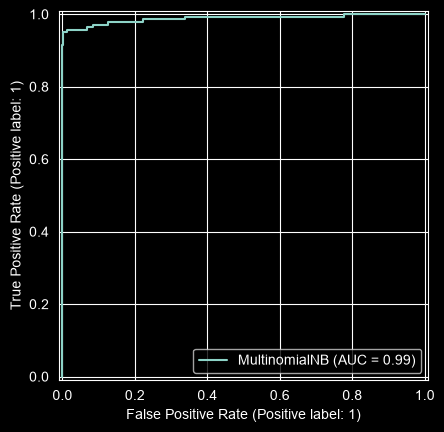

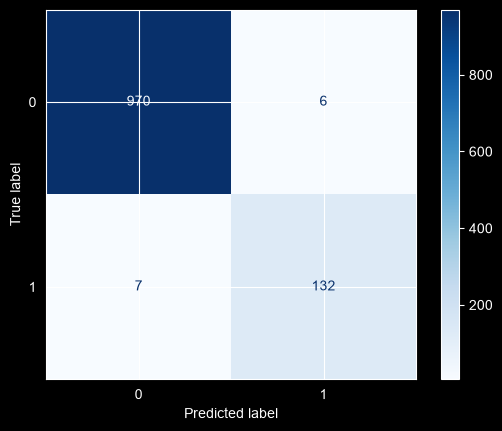

In [293]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# ROC 曲线
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show('lr_roc_curve.png')

# 混淆矩阵热力图
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.show('lr_confusion_matrix.png')